# 🧬 Pipeline RNA-seq
## HISAT2 → StringTie → DESeq2

**Auteur :** DrArvJ.K.D  
**Date :** 2025-03-21  
**Référence :** Griffith Lab, CSHL 2025

---

### Étapes
1. Contrôle qualité (FastQC + MultiQC)
2. Indexation du génome (HISAT2-build)
3. Alignement (HISAT2)
4. QC post-alignement
5. Quantification (StringTie + featureCounts)
6. Expression différentielle (DESeq2)

# 🟢 Cellule 2 — Configuration (cellule Code)

In [2]:
import os
from pathlib import Path
os.environ["PATH"] = "/opt/conda/envs/rnaseq_env/bin:" + os.environ["PATH"]

# ─── Répertoires ──────────────────────────────────────────────
BASE_DIR  = Path("..")
DATA_RAW  = BASE_DIR / "data" / "raw"
DATA_REF  = BASE_DIR / "data" / "reference"
DATA_BAM  = BASE_DIR / "data" / "processed" / "bam"
RES_QC    = BASE_DIR / "results" / "01_fastqc"
RES_ALIGN = BASE_DIR / "results" / "02_alignment"
RES_ABUND = BASE_DIR / "results" / "03_abundance"
RES_DE    = BASE_DIR / "results" / "04_differential_expression"
RES_FIG   = BASE_DIR / "results" / "05_figures"
LOGS      = BASE_DIR / "logs"

# ─── Paramètres ───────────────────────────────────────────────
N_THREADS = 8
GTF       = DATA_REF / "chr22_with_ERCC92.gtf"
GENOME    = DATA_REF / "chr22_with_ERCC92.fa"
INDEX     = DATA_REF / "hisat2_index" / "chr22"

# ─── Créer les dossiers manquants ─────────────────────────────
for d in [DATA_RAW, DATA_REF, DATA_BAM, RES_QC, RES_ALIGN,
          RES_ABUND, RES_DE, RES_FIG, LOGS, INDEX.parent]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Répertoires prêts")
print(f"   Base    : {BASE_DIR.resolve()}")
print(f"   Threads : {N_THREADS}")

✅ Répertoires prêts
   Base    : /data/jwd07/pulsar_staging/98584065/working/jupyter/galaxy_inputs/rnaseq_analysis
   Threads : 8


# 🟢 Cellule 3 — Téléchargement des données de test (cellule Code)

In [18]:
# fichier fastq
!wget -q -P{DATA_RAW} http://genomedata.org/rnaseq-tutorial/HBR_UHR_ERCC_ds_5pc.tar

In [21]:
#decompresse les fichiers fastqc
!tar xf HBR_UHR_ERCC_ds_5pc.tar -C {DATA_RAW}

In [14]:
# TELECHARGER chr22_with_ERCC92.fa
!wget -q -P{DATA_REF} http://genomedata.org/rnaseq-tutorial/fasta/GRCh38/chr22_with_ERCC92.fa

## TELECHARGER Homo_sapiens.GRCh378_chr22_ERCC.gtf
!wget -q -P{DATA_REF} http://genomedata.org/rnaseq-tutorial/annotations/GRCh38/chr22_with_ERCC92.gtf


In [3]:
#regarde si le telechargement a ete bien fait
!ls -lh {DATA_RAW}
!ls -lh {DATA_REF}

total 223M
-rw-r--r--. 1 jovyan users 6.4M Nov  6  2014 HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22.read1.fastq.gz
-rw-r--r--. 1 jovyan users 6.7M Nov  6  2014 HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22.read2.fastq.gz
-rw-r--r--. 1 jovyan users 7.7M Nov  6  2014 HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22.read1.fastq.gz
-rw-r--r--. 1 jovyan users 8.1M Nov  6  2014 HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22.read2.fastq.gz
-rw-r--r--. 1 jovyan users 6.9M Nov  6  2014 HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22.read1.fastq.gz
-rw-r--r--. 1 jovyan users 7.3M Nov  6  2014 HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22.read2.fastq.gz
-rw-r--r--. 1 jovyan users 112M Oct 23  2018 HBR_UHR_ERCC_ds_5pc.tar
-rw-r--r--. 1 jovyan users  13M Nov  6  2014 UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.read1.fastq.gz
-rw-r--r--. 1 jovyan users  14M Nov  6  2014 UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.read2.fastq.gz
-rw-r--r--. 1 jovyan users 9.7M Nov  6  2014 UHR

# 🟢 Cellule 4 — FastQC (contrôle qualité des reads)

In [8]:
!fastqc {DATA_RAW}/*.fastq.gz \
        --outdir {RES_QC} \
        --threads {N_THREADS} \
        2>&1 | tail -5

Approx 80% complete for UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22.read2.fastq.gz
Approx 85% complete for UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22.read2.fastq.gz
Approx 90% complete for UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22.read2.fastq.gz
Approx 95% complete for UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22.read2.fastq.gz
Analysis complete for UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22.read2.fastq.gz


# 🟢 Cellule 5 — MultiQC (agrège tous les rapports FastQC)

In [9]:
# MultiQC agrège tous les rapports FastQC en un seul rapport HTML
# - cherche dans RES_QC tous les fichiers FastQC reconnus
# - fusionne en un seul rapport HTML
# - --force : écrase si le rapport existe déjà
!multiqc {RES_QC} \
         --outdir {RES_QC} \
         --filename multiqc_report.html \
         --force \
         2>&1 | tail -5

|         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 24/24  0m  
|            fastqc | Found 12 reports
|           multiqc | Report      : ../results/01_fastqc/multiqc_report.html
|           multiqc | Data        : ../results/01_fastqc/multiqc_report_data
|           multiqc | MultiQC complete


# 🟢 Cellule 6 — Indexation du génome (HISAT2-build)

In [10]:
# Indexation du génome de référence avec HISAT2
# - opération à faire une seule fois par génome
# - crée ~8 fichiers .ht2 dans le dossier hisat2_index/
!hisat2-build \
    {GENOME} \
    {INDEX} \
    -p {N_THREADS} \
    2>&1 | tail -5

    gbwtTotLen: 13080896
    gbwtTotSz: 13080896
    reverse: 0
    linearFM: Yes
Total time for call to driver() for forward index: 00:01:02


In [11]:
# Vérification des fichiers d'index créés par HISAT2
!ls -lh {DATA_REF}/hisat2_index/

total 62M
-rw-r--r--. 1 jovyan users  17M Mar 21 19:46 chr22.1.ht2
-rw-r--r--. 1 jovyan users 9.4M Mar 21 19:46 chr22.2.ht2
-rw-r--r--. 1 jovyan users 1.3K Mar 21 19:45 chr22.3.ht2
-rw-r--r--. 1 jovyan users 9.4M Mar 21 19:45 chr22.4.ht2
-rw-r--r--. 1 jovyan users  18M Mar 21 19:46 chr22.5.ht2
-rw-r--r--. 1 jovyan users 9.6M Mar 21 19:46 chr22.6.ht2
-rw-r--r--. 1 jovyan users   12 Mar 21 19:45 chr22.7.ht2
-rw-r--r--. 1 jovyan users    8 Mar 21 19:45 chr22.8.ht2


# 🟢 Cellule 7 — Alignement test UHR_Rep1 sans strandness

In [12]:
# Alignement test sur un seul échantillon SANS --rna-strandness
# But : déterminer le strandness avant d'aligner tous les échantillons
os.system(
    f"hisat2 -p {N_THREADS} --dta "
    f"-x {INDEX} "
    f"-1 {DATA_RAW}/UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.read1.fastq.gz "
    f"-2 {DATA_RAW}/UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.read2.fastq.gz "
    f"2>{LOGS}/UHR_Rep1_test.log | "
    f"samtools sort -@ {N_THREADS} -o {DATA_BAM}/UHR_Rep1_test.sorted.bam"
)
os.system(f"samtools index {DATA_BAM}/UHR_Rep1_test.sorted.bam")
print("✅ BAM test créé")

[bam_sort_core] merging from 0 files and 8 in-memory blocks...


✅ BAM test créé


In [53]:
# On s'assure que l'alignement se fait bien
!samtools flagstat {DATA_BAM}/UHR_Rep1_test.sorted.bam

462957 + 0 in total (QC-passed reads + QC-failed reads)
454784 + 0 primary
8173 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
461882 + 0 mapped (99.77% : N/A)
453709 + 0 primary mapped (99.76% : N/A)
454784 + 0 paired in sequencing
227392 + 0 read1
227392 + 0 read2
451596 + 0 properly paired (99.30% : N/A)
452916 + 0 with itself and mate mapped
793 + 0 singletons (0.17% : N/A)
4 + 0 with mate mapped to a different chr
4 + 0 with mate mapped to a different chr (mapQ>=5)


In [52]:
!which gtfToGenePred

/opt/conda/envs/rnaseq_env/bin/gtfToGenePred


In [37]:
# Conversion du GTF en BED (format requis par infer_experiment.py)
# gtfToGenePred → genePredToBed : deux conversions successives
!gtfToGenePred {GTF} /tmp/chr22.genePred
!genePredToBed /tmp/chr22.genePred {DATA_REF}/chr22_with_ERCC92.bed

# Vérification du fichier BED créé
!wc -l {DATA_REF}/chr22_with_ERCC92.bed

4564 ../data/reference/chr22_with_ERCC92.bed


In [55]:
# Vérifier le format des chromosomes dans le BAM. on regarde aussi si le nom du chromosome est le meme
# dans le fichier bAM et bed
!samtools view {DATA_BAM}/UHR_Rep1_test.sorted.bam | head -1 

HWI-ST718_146963544:5:2208:13984:35958	163	22	10836084	1	100M	=	10836228	244	CACAAAGAAGCAAACTGTGTCCTGAACAGTTTTGCAAACTCTGTAGTTGGTAGTATTCTTTTCACACGTCTTTCTTGTCGTTCTTTTTAACAACAGTCAT	CCCFFFDFHHHHHJJIIHGIJJJJIJIIJHGHIIIIIJJIIIGGIIIIIICFGIHIJEIHIIDGIIJJHGIJJIGJIHHHEFBBDEEECCACDDDDA:AD	AS:i:0	ZS:i:0	XN:i:0	XM:i:0	XO:i:0	XG:i:0	NM:i:0	MD:Z:100	YS:i:-6	YT:Z:CP	NH:i:2
samtools view: writing to standard output failed: Broken pipe
samtools view: error closing standard output: -1


In [50]:
!ls /opt/conda/envs/rnaseq_env/bin/samtools

ls: cannot access '/opt/conda/envs/rnaseq_env/bin/samtools': No such file or directory


# 🟢 Vérifie le strandness avec infer_experiment.py
est un outil du package RSeQC. Il répond à la question : "Dans quel sens mes reads ont-ils été séquencés ?"

In [56]:
# infer_experiment.py analyse 200 000 reads du BAM
# et compare leur orientation avec le GTF
# pour deviner si la librairie est stranded ou non
!infer_experiment.py \
    -r {DATA_REF}/chr22_with_ERCC92.bed \
    -i {DATA_BAM}/UHR_Rep1_test.sorted.bam \
    2>&1 | tail -20

Reading reference gene model ../data/reference/chr22_with_ERCC92.bed ... Done
Loading SAM/BAM file ...  Total 200000 usable reads were sampled


This is PairEnd Data
Fraction of reads failed to determine: 0.0781
Fraction of reads explained by "1++,1--,2+-,2-+": 0.0126
Fraction of reads explained by "1+-,1-+,2++,2--": 0.9092


# 🟢 Cellule 7 — Alignement avec HISAT2

In [57]:
# Échantillons à traiter
samples = [
    "UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22",
    "UHR_Rep2_ERCC-Mix1_Build37-ErccTranscripts-chr22",
    "UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22",
    "HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22",
    "HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22",
    "HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22",
]

In [58]:
# Alignement + tri + indexation de tous les échantillons
for s in samples:

    # Chemins des fichiers d'entrée et sortie
    r1         = f"{DATA_RAW}/{s}.read1.fastq.gz"
    r2         = f"{DATA_RAW}/{s}.read2.fastq.gz"
    sorted_bam = f"{DATA_BAM}/{s}.sorted.bam"
    log        = f"{LOGS}/{s}_hisat2.log"

    print(f"\n=== Traitement de {s} ===")

    # HISAT2 → samtools sort en un seul pipe (pas de fichier SAM intermédiaire)
    os.system(
        f"hisat2 -p {N_THREADS} --dta --rna-strandness RF "
        f"-x {INDEX} -1 {r1} -2 {r2} 2>{log} | "
        f"samtools sort -@ {N_THREADS} -o {sorted_bam}"
    )

    # Indexation du BAM trié
    os.system(f"samtools index {sorted_bam}")

    print(f"✅ {s} → {sorted_bam}")

print("\n✅ Tous les échantillons sont alignés !")


=== Traitement de UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22 ===


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


✅ UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22 → ../data/processed/bam/UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam

=== Traitement de UHR_Rep2_ERCC-Mix1_Build37-ErccTranscripts-chr22 ===


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


✅ UHR_Rep2_ERCC-Mix1_Build37-ErccTranscripts-chr22 → ../data/processed/bam/UHR_Rep2_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam

=== Traitement de UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22 ===


...

✅ HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22 → ../data/processed/bam/HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam

=== Traitement de HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22 ===


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


✅ HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22 → ../data/processed/bam/HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam

=== Traitement de HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22 ===


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


✅ HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22 → ../data/processed/bam/HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam

✅ Tous les échantillons sont alignés !


In [59]:
# Vérification des taux d'alignement pour chaque échantillon
# Le log HISAT2 contient les statistiques d'alignement
for s in samples:
    log = f"{LOGS}/{s}_hisat2.log"
    print(f"\n{s.split('_')[0]}_{s.split('_')[1]} :")
    os.system(f"grep 'overall alignment rate' {log}")


UHR_Rep1 :
99.76% overall alignment rate

UHR_Rep2 :
99.78% overall alignment rate

UHR_Rep3 :
99.76% overall alignment rate

HBR_Rep1 :
99.84% overall alignment rate

HBR_Rep2 :
99.85% overall alignment rate

HBR_Rep3 :
99.85% overall alignment rate


# 🟢 Cellule suivante — StringTie (quantification)

In [60]:
# Quantification de l'expression avec StringTie
# -G  : utilise le GTF comme référence
# -e  : mode reference only (pas de nouveaux transcrits)
# -B  : génère les fichiers pour Ballgown
# -p  : nombre de threads
# -o  : fichier GTF de sortie
# -A  : fichier d'abondance des gènes (TPM/FPKM)
for s in samples:
    sorted_bam = f"{DATA_BAM}/{s}.sorted.bam"
    out_dir    = f"{RES_ABUND}/{s}"
    out_gtf    = f"{out_dir}/{s}.gtf"
    out_abund  = f"{out_dir}/{s}_gene_abund.tsv"

    # Créer le dossier de sortie
    os.makedirs(out_dir, exist_ok=True)

    print(f"🔄 StringTie : {s.split('_')[0]}_{s.split('_')[1]}...")

    os.system(
        f"stringtie {sorted_bam} "
        f"-G {GTF} -e -B "
        f"-p {N_THREADS} "
        f"-o {out_gtf} "
        f"-A {out_abund}"
    )
    print(f"✅ {s.split('_')[0]}_{s.split('_')[1]} terminé")

print("\n✅ StringTie terminé pour tous les échantillons !")

🔄 StringTie : UHR_Rep1...
✅ UHR_Rep1 terminé
🔄 StringTie : UHR_Rep2...
✅ UHR_Rep2 terminé
🔄 StringTie : UHR_Rep3...
✅ UHR_Rep3 terminé
🔄 StringTie : HBR_Rep1...
✅ HBR_Rep1 terminé
🔄 StringTie : HBR_Rep2...
✅ HBR_Rep2 terminé
🔄 StringTie : HBR_Rep3...
✅ HBR_Rep3 terminé

✅ StringTie terminé pour tous les échantillons !


In [61]:
# Vérification des fichiers générés par StringTie
!ls {RES_ABUND}/

HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22
HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22
HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22
UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22
UHR_Rep2_ERCC-Mix1_Build37-ErccTranscripts-chr22
UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22


In [62]:
# Vérification des fichiers dans un dossier StringTie
!ls {RES_ABUND}/UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22/

UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.gtf		 i2t.ctab
UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22_gene_abund.tsv  i_data.ctab
e2t.ctab							 t_data.ctab
e_data.ctab


# 🟢 Cellule suivante — featureCounts (raw counts pour DESeq2)

In [63]:
# featureCounts compte le nombre de reads par gène
# -T  : nombre de threads
# -a  : fichier GTF d'annotation
# -o  : fichier de sortie (matrice de counts)
# -g  : attribut du GTF pour grouper (gene_id)
# -t  : type de feature à compter (exon)
# -p  : données paired-end
# -s 2: stranded reverse (RF confirmé par infer_experiment.py)

# Liste de tous les BAM
bam_files = " ".join([
    f"{DATA_BAM}/{s}.sorted.bam" for s in samples
])

os.system(
    f"featureCounts "
    f"-T {N_THREADS} "
    f"-a {GTF} "
    f"-o {RES_ABUND}/counts_matrix.tsv "
    f"-g gene_id "
    f"-t exon "
    f"-p "
    f"-s 2 "
    f"{bam_files} "
    f"2>{LOGS}/featurecounts.log"
)

print("✅ featureCounts terminé !")

✅ featureCounts terminé !


In [3]:
# Aperçu de la matrice de counts bruts
# Installation de pandas dans l'environnement actif
import pandas as pd

# Charger la matrice (les 2 premières lignes sont des commentaires)
counts_raw = pd.read_csv(f"{RES_ABUND}/counts_matrix.tsv", sep="\t", comment="#")

# Afficher les dimensions
print(f"Dimensions : {counts_raw.shape[0]} gènes × {counts_raw.shape[1]} colonnes")
print(f"\nColonnes : {list(counts_raw.columns)}")
print(f"\nAperçu :")
display(counts_raw.head())

Dimensions : 1410 gènes × 12 colonnes

Colonnes : ['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', '../data/processed/bam/UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam', '../data/processed/bam/UHR_Rep2_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam', '../data/processed/bam/UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam', '../data/processed/bam/HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam', '../data/processed/bam/HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam', '../data/processed/bam/HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam']

Aperçu :


,Geneid,Chr,Start,End,Strand,Length,../data/processed/bam/UHR_Rep1_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam,../data/processed/bam/UHR_Rep2_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam,../data/processed/bam/UHR_Rep3_ERCC-Mix1_Build37-ErccTranscripts-chr22.sorted.bam,../data/processed/bam/HBR_Rep1_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam,../data/processed/bam/HBR_Rep2_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam,../data/processed/bam/HBR_Rep3_ERCC-Mix2_Build37-ErccTranscripts-chr22.sorted.bam
0,ENSG00000277248,22,10736171,10736283,-,113,0,0,0,0,0,0
1,ENSG00000283047,22;22;22;22;22;22;22;22;22,10939388;10940597;10941691;10944967;10947304;1...,10939423;10940707;10941780;10945053;10947418;1...,-;-;-;-;-;-;-;-;-,749,0,0,0,0,0,0
2,ENSG00000280363,22;22,11065974;11067335,11066015;11067346,-;-,54,0,0,0,0,0,0
3,ENSG00000279973,22;22,11066501;11067985,11066515;11068089,+;+,120,0,0,0,0,0,0
4,ENSG00000226444,22;22,11124337;11124508,11124379;11125705,+;+,1241,0,0,0,0,0,0


In [4]:
# Nettoyage de la matrice de counts
# - Garder seulement Geneid + colonnes de counts
# - Renommer les colonnes avec des noms courts
# - Filtrer les gènes avec 0 counts partout

# Garder seulement Geneid + les 6 colonnes de counts (enlever Chr, Start, End, Strand, Length)
counts = counts_raw.set_index("Geneid").iloc[:, 5:]

# Renommer les colonnes avec des noms courts
counts.columns = [
    "UHR_Rep1", "UHR_Rep2", "UHR_Rep3",
    "HBR_Rep1", "HBR_Rep2", "HBR_Rep3"
]

# Filtrer les gènes avec 0 counts dans tous les échantillons
counts = counts[counts.sum(axis=1) > 0]

print(f"Gènes après filtre : {counts.shape[0]}")
print(f"\nAperçu de la matrice propre :")
display(counts.head(10))

# Sauvegarder
counts.to_csv(f"{RES_ABUND}/counts_clean.csv")
print(f"\n✅ Matrice sauvegardée : {RES_ABUND}/counts_clean.csv")

Gènes après filtre : 925

Aperçu de la matrice propre :


,UHR_Rep1,UHR_Rep2,UHR_Rep3,HBR_Rep1,HBR_Rep2,HBR_Rep3
Geneid,,,,,,
ENSG00000236235,0,0,1,0,0,0
ENSG00000279442,0,4,0,0,0,0
ENSG00000184624,0,2,0,0,0,0
ENSG00000236097,0,1,0,0,0,0
ENSG00000237299,0,1,0,0,0,0
ENSG00000235759,0,4,0,0,0,0
ENSG00000233408,0,2,0,0,0,0
ENSG00000215268,0,4,0,0,0,0
ENSG00000230471,0,2,0,0,0,0



✅ Matrice sauvegardée : ../results/03_abundance/counts_clean.csv


# 🟢 Cellule suivante — DESeq2 (en R)

In [1]:
# Chargement des librairies R
suppressMessages({
  library(DESeq2)
  library(ggplot2)
  library(pheatmap)
  library(RColorBrewer)
  library(ggrepel)
  library(dplyr)
})

cat("✅ Librairies chargées\n")
cat("DESeq2 version :", as.character(packageVersion("DESeq2")), "\n")

✅ Librairies chargées
DESeq2 version : 1.42.0 


In [2]:
# Chargement de la matrice de counts
counts_mat <- read.csv("../results/03_abundance/counts_clean.csv", row.names=1)

# Vérification
cat("Dimensions :", dim(counts_mat), "\n")
cat("Échantillons :", colnames(counts_mat), "\n")
head(counts_mat)

Dimensions : 925 6 
Échantillons : UHR_Rep1 UHR_Rep2 UHR_Rep3 HBR_Rep1 HBR_Rep2 HBR_Rep3 


,UHR_Rep1,UHR_Rep2,UHR_Rep3,HBR_Rep1,HBR_Rep2,HBR_Rep3
,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000236235,0,0,1,0,0,0
ENSG00000279442,0,4,0,0,0,0
ENSG00000184624,0,2,0,0,0,0
ENSG00000236097,0,1,0,0,0,0
ENSG00000237299,0,1,0,0,0,0
ENSG00000235759,0,4,0,0,0,0


In [3]:
# Définition des métadonnées des échantillons
# condition : UHR (lignées cellulaires) vs HBR (cerveau)
colData <- data.frame(
  row.names = colnames(counts_mat),
  condition = factor(c("UHR", "UHR", "UHR",
                       "HBR", "HBR", "HBR"))
)

cat("Design expérimental :\n")
print(colData)

# Vérification que les noms correspondent
stopifnot(all(rownames(colData) == colnames(counts_mat)))
cat("\n✅ Métadonnées correctes\n")

Design expérimental :
         condition
UHR_Rep1       UHR
UHR_Rep2       UHR
UHR_Rep3       UHR
HBR_Rep1       HBR
HBR_Rep2       HBR
HBR_Rep3       HBR

✅ Métadonnées correctes


In [4]:
# Création de l'objet DESeq2
dds <- DESeqDataSetFromMatrix(
  countData = round(as.matrix(counts_mat)),  # DESeq2 requiert des entiers
  colData   = colData,
  design    = ~ condition                     # comparer par condition
)

# Filtrage : garder les gènes avec au moins 10 counts au total
keep <- rowSums(counts(dds)) >= 10
dds  <- dds[keep, ]

cat(sprintf("Gènes avant filtre : %d\n", nrow(counts_mat)))
cat(sprintf("Gènes après filtre : %d\n", sum(keep)))

converting counts to integer mode



Gènes avant filtre : 925
Gènes après filtre : 638


In [5]:
# Analyse DESeq2 en une commande
# Réalise en séquence :
#   1. Estimation des size factors (normalisation)
#   2. Estimation de la dispersion
#   3. Test de Wald (HBR vs UHR)
dds <- DESeq(dds)

# Extraire les résultats HBR vs UHR
# alpha = seuil FDR
res <- results(
  dds,
  contrast       = c("condition", "HBR", "UHR"),
  alpha          = 0.05,
  pAdjustMethod  = "BH"   # Benjamini-Hochberg
)

summary(res)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing




out of 638 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 171, 27%
LFC < 0 (down)     : 180, 28%
outliers [1]       : 0, 0%
low counts [2]     : 13, 2%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Volcano plot — HBR vs UHR' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Volcano plot — HBR vs UHR' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Volcano plot — HBR vs UHR' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Volcano plot — HBR vs UHR' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Volcano plot — HBR vs UHR' in 'mbcsToSbcs': dot substituted for <80>”
W

✅ Volcano plot sauvegardé


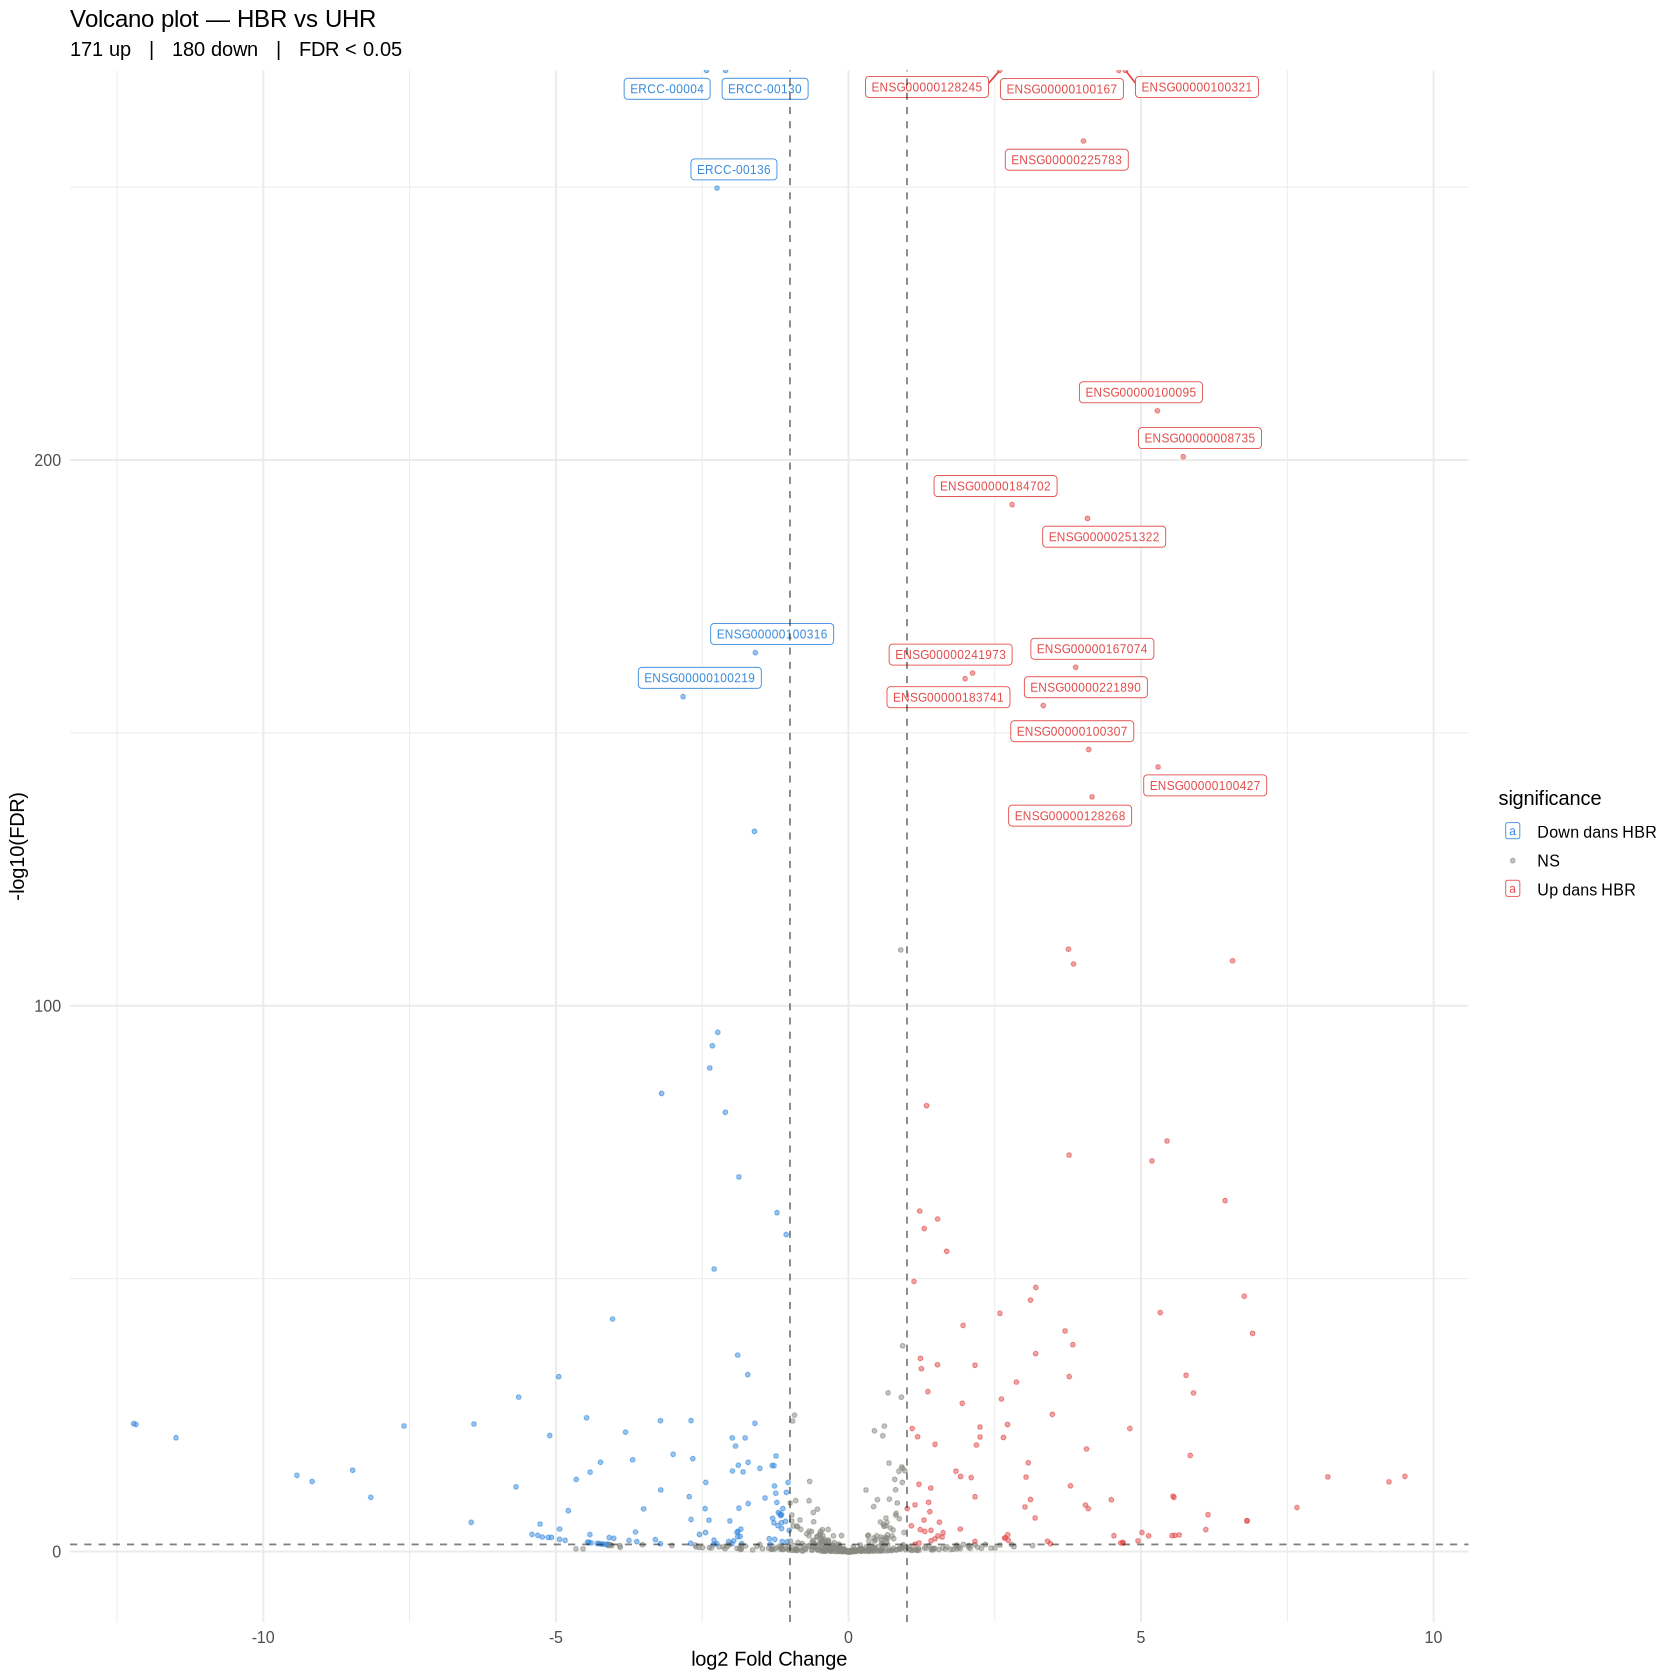

In [8]:
# Volcano plot — visualisation des résultats
res_df <- as.data.frame(res) %>%
  tibble::rownames_to_column("gene") %>%
  mutate(
    significance = case_when(
      padj < 0.05 & log2FoldChange >  1  ~ "Up dans HBR",
      padj < 0.05 & log2FoldChange < -1  ~ "Down dans HBR",
      TRUE                               ~ "NS"
    )
  )

# Top 20 gènes les plus significatifs
top_genes <- res_df %>%
  filter(significance != "NS") %>%
  arrange(padj) %>%
  head(20)

# Volcano plot
p <- ggplot(res_df, aes(x=log2FoldChange, y=-log10(padj), color=significance)) +
  geom_point(alpha=0.5, size=1) +
  geom_label_repel(data=top_genes, aes(label=gene), size=2.5, max.overlaps=15) +
  scale_color_manual(values=c(
    "Up dans HBR"   = "#E24B4A",
    "Down dans HBR" = "#378ADD",
    "NS"            = "#888780"
  )) +
  geom_vline(xintercept=c(-1, 1), linetype="dashed", alpha=0.5) +
  geom_hline(yintercept=-log10(0.05), linetype="dashed", alpha=0.5) +
  labs(
    title    = "Volcano plot — HBR vs UHR",
    x        = "log2 Fold Change",
    y        = "-log10(FDR)",
    subtitle = paste0("171 up   |   180 down   |   FDR < 0.05")
  ) +
  theme_minimal(base_size=12)
options(repr.plot.width=14, repr.plot.height=14)
print(p)

# Sauvegarder
ggsave(
  filename = "../results/05_figures/volcano_plot.pdf",
  plot     = p,
  width    = 8,
  height   = 6
)
cat("✅ Volcano plot sauvegardé\n")

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 50 gènes — Expression normalisée (VST)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 50 gènes — Expression normalisée (VST)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 50 gènes — Expression normalisée (VST)' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 50 gènes — Expression normalisée (VST)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 50 gènes — Expression normalisée (VST)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_text

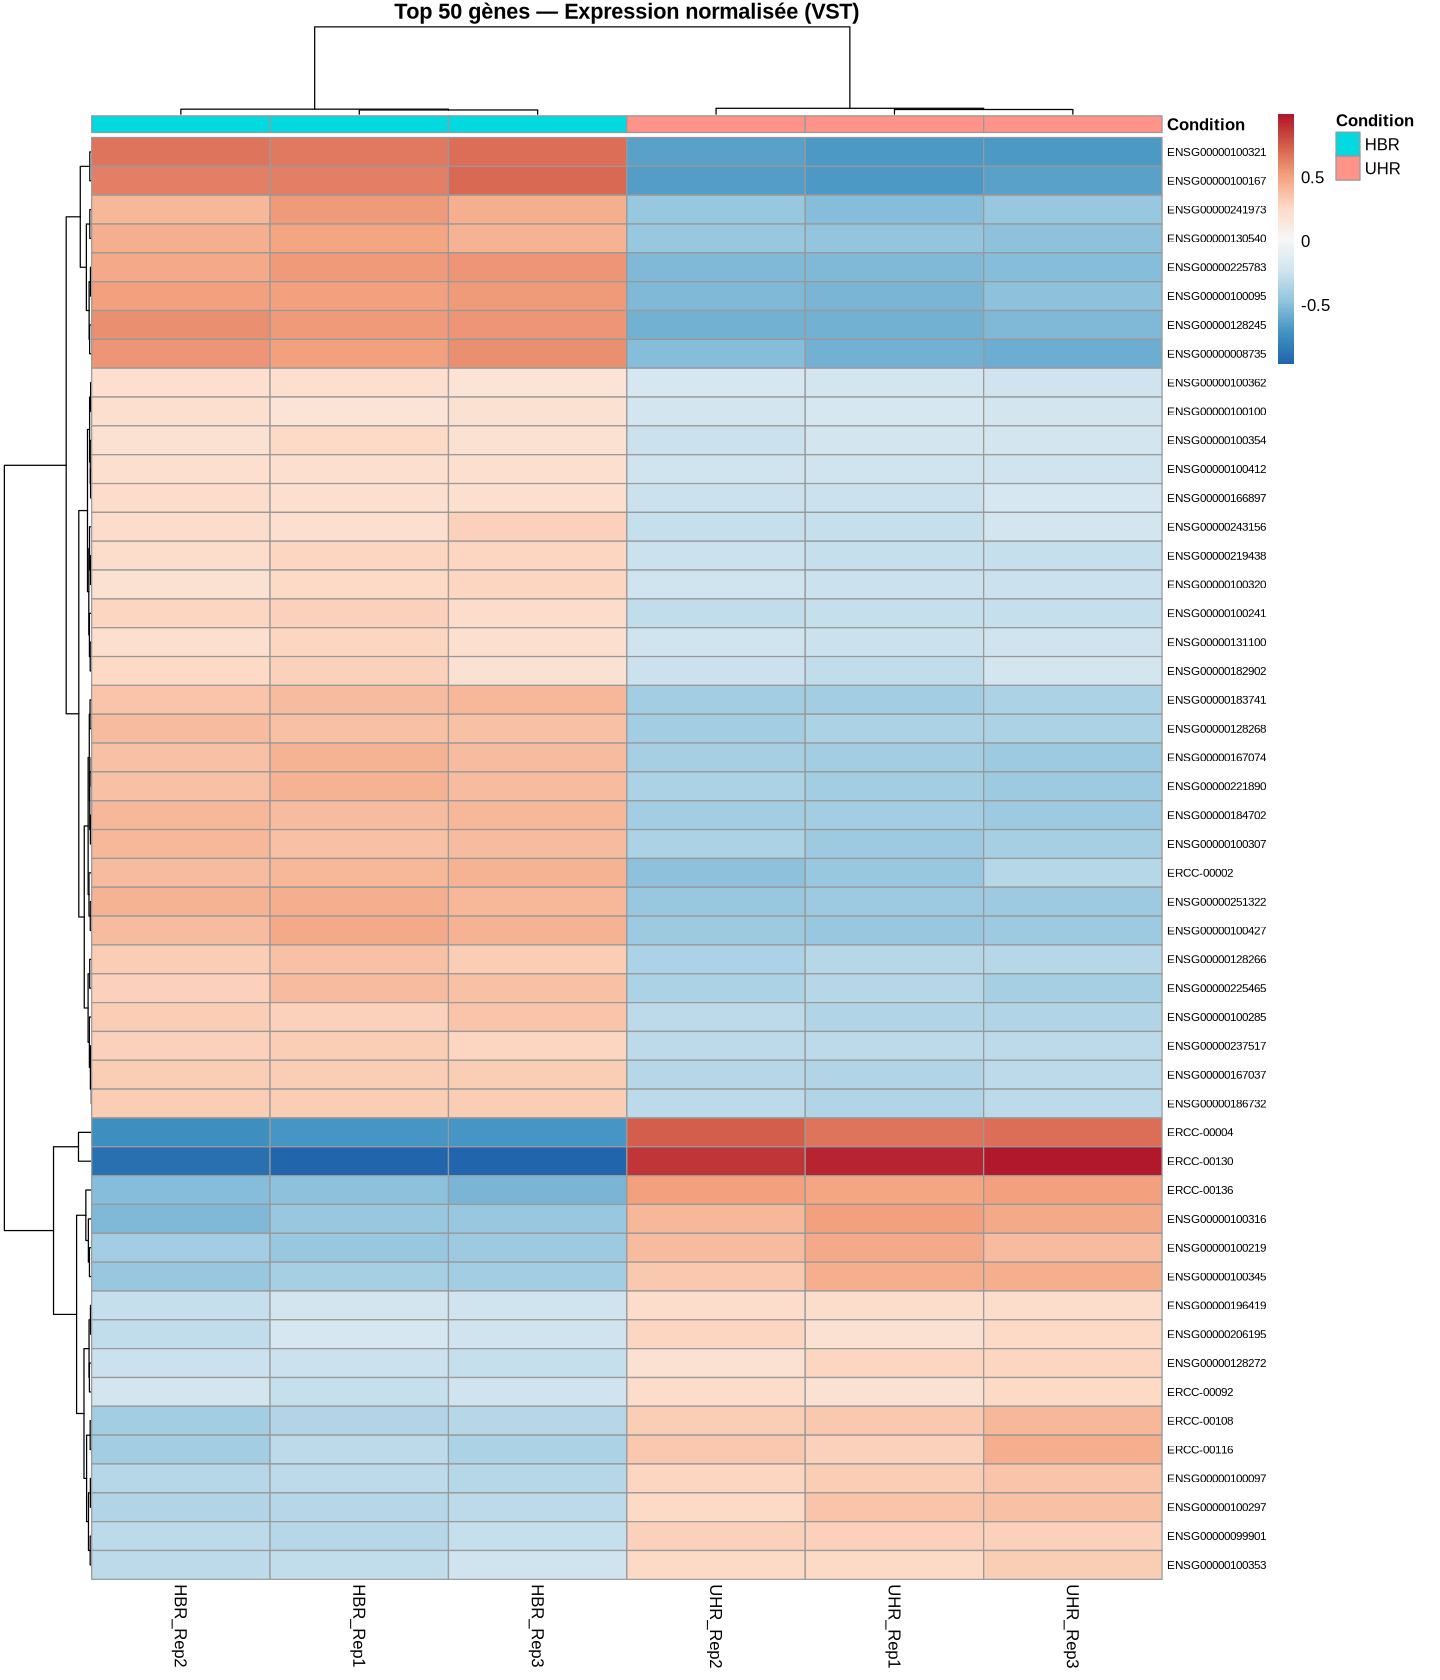

In [10]:
# Heatmap des top 50 gènes différentiellement exprimés
# vst : variance stabilizing transformation
# centre les données pour mieux voir les patterns

# Transformation VST (stabilise la variance)
vsd <- varianceStabilizingTransformation(dds, blind=FALSE)

# Top 50 gènes les plus significatifs
top50 <- res_df %>%
  filter(!is.na(padj)) %>%
  arrange(padj) %>%
  head(50) %>%
  pull(gene)

# Matrice centrée
mat <- assay(vsd)[top50, ]
mat <- mat - rowMeans(mat)

# Annotation des colonnes
annotation_col <- data.frame(
  Condition = colData$condition,
  row.names = rownames(colData)
)

# Heatmap
options(repr.plot.width=12, repr.plot.height=14)
pheatmap(
  mat,
  annotation_col = annotation_col,
  cluster_rows   = TRUE,
  cluster_cols   = TRUE,
  show_rownames  = TRUE,
  fontsize_row   = 7,
  color          = colorRampPalette(rev(brewer.pal(9, "RdBu")))(100),
  main           = "Top 50 gènes — Expression normalisée (VST)"
)

In [11]:
# Export des résultats DESeq2
res_ordered <- res_df %>%
  filter(!is.na(padj)) %>%
  arrange(padj)

# Tous les gènes testés
write.csv(
  res_ordered,
  file      = "../results/04_differential_expression/DESeq2_results.csv",
  row.names = FALSE
)

# Seulement les significatifs (FDR < 0.05 et |log2FC| > 1)
res_sig <- res_ordered %>%
  filter(padj < 0.05, abs(log2FoldChange) > 1)

write.csv(
  res_sig,
  file      = "../results/04_differential_expression/DESeq2_significant.csv",
  row.names = FALSE
)

cat(sprintf("✅ Résultats exportés :\n"))
cat(sprintf("   Tous les gènes testés    : %d\n", nrow(res_ordered)))
cat(sprintf("   Gènes significatifs      : %d\n", nrow(res_sig)))

✅ Résultats exportés :
   Tous les gènes testés    : 625
   Gènes significatifs      : 250


In [ ]:
# 